<a href="https://colab.research.google.com/github/palak0626/predictive-analysis/blob/main/topsis2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# dataset

In [10]:
data = pd.DataFrame({
    'Model': ['GPT-2', 'T5', 'BART', 'DialoGPT'],
    'BLEU': [0.75, 0.80, 0.78, 0.70],
    'ROUGE': [0.70, 0.78, 0.76, 0.68],
    'Time': [2.5, 3.0, 2.8, 2.0],
    'Size': [500, 600, 550, 400]
})

data

,Model,BLEU,ROUGE,Time,Size
0,GPT-2,0.75,0.70,2.5,500
1,T5,0.80,0.78,3.0,600
2,BART,0.78,0.76,2.8,550
3,DialoGPT,0.70,0.68,2.0,400


# normalize

In [11]:
matrix = data.iloc[:, 1:].values

norm = matrix / np.sqrt((matrix**2).sum(axis=0))

norm_df = pd.DataFrame(norm, columns=['BLEU','ROUGE','Time','Size'])
norm_df

,BLEU,ROUGE,Time,Size
0,0.494439,0.478689,0.480325,0.482805
1,0.527401,0.533396,0.576390,0.579365
2,0.514216,0.519720,0.537964,0.531085
3,0.461476,0.465012,0.384260,0.386244


# apply weights

In [12]:
weights = np.array([0.3, 0.3, 0.2, 0.2])

weighted_matrix = norm * weights

weighted_df = pd.DataFrame(weighted_matrix, columns=['BLEU','ROUGE','Time','Size'])
weighted_df

,BLEU,ROUGE,Time,Size
0,0.148332,0.143607,0.096065,0.096561
1,0.158220,0.160019,0.115278,0.115873
2,0.154265,0.155916,0.107593,0.106217
3,0.138443,0.139504,0.076852,0.077249


In [13]:
ideal_best = np.array([
    max(weighted_matrix[:,0]),
    max(weighted_matrix[:,1]),
    min(weighted_matrix[:,2]),
    min(weighted_matrix[:,3])
])

ideal_worst = np.array([
    min(weighted_matrix[:,0]),
    min(weighted_matrix[:,1]),
    max(weighted_matrix[:,2]),
    max(weighted_matrix[:,3])
])

ideal_best, ideal_worst

(array([0.15822036, 0.16001894, 0.07685206, 0.07724873]),
 array([0.13844282, 0.13950369, 0.11527808, 0.11587309]))

In [14]:
d_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))
d_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

In [15]:
score = d_worst / (d_best + d_worst)

data['Score'] = score
data['Rank'] = data['Score'].rank(ascending=False)

result = data.sort_values('Rank')
result

,Model,BLEU,ROUGE,Time,Size,Score,Rank
3,DialoGPT,0.70,0.68,2.0,400,0.656587,1.0
0,GPT-2,0.75,0.70,2.5,500,0.467754,2.0
2,BART,0.78,0.76,2.8,550,0.378189,3.0
1,T5,0.80,0.78,3.0,600,0.343413,4.0


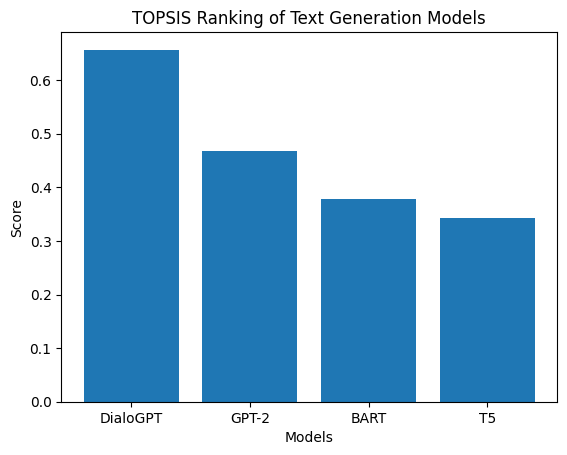

In [16]:
plt.figure()
plt.bar(result['Model'], result['Score'])
plt.title("TOPSIS Ranking of Text Generation Models")
plt.xlabel("Models")
plt.ylabel("Score")
plt.show()